In [23]:
import os
import pickle
import numpy as np

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [25]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [26]:
DATA_DIR = '/content/drive/MyDrive/flood_detection_project/data/processed'

with open(os.path.join(DATA_DIR, 'test.pkl'), 'rb') as f:
  test_data = pickle.load(f)

print(len(test_data))

41


In [27]:
def center_crop_to_match(enc_feat, dec_feat):
  _, _, h, w = dec_feat.shape
  enc_h, enc_w = enc_feat.shape[2], enc_feat.shape[3]

  sh = (enc_h - h) // 2
  sw = (enc_w - w) // 2

  return enc_feat[:, :, sh:sh+h, sw:sw+w]

In [28]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


In [29]:
class UNet(nn.Module):
    def __init__(self, in_channels=4):
        super().__init__()

        self.enc1 = DoubleConv(in_channels, 64)
        self.enc2 = DoubleConv(64, 128)
        self.enc3 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(256, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = DoubleConv(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = DoubleConv(256, 128)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = DoubleConv(128, 64)

        self.out = nn.Conv2d(64, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        b = self.bottleneck(self.pool(e3))

        d3 = self.up3(b)
        e3c = center_crop_to_match(e3, d3)
        d3 = self.dec3(torch.cat([d3, e3c], dim=1))

        d2 = self.up2(d3)
        e2c = center_crop_to_match(e2, d2)
        d2 = self.dec2(torch.cat([d2, e2c], dim=1))
        d1 = self.up1(d2)
        e1c = center_crop_to_match(e1, d1)
        d1 = self.dec1(torch.cat([d1, e1c], dim=1))

        return self.out(d1)


In [30]:
MODEL_PATH = '/content/drive/MyDrive/flood_detection_project/models/unet_30epochs.pth'

model = UNet(in_channels=4).to(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("model loaded")

model loaded


In [31]:
for X, y in test_data:
  if y ==1:
    sample_X = X
    break

print("sample shape: ", sample_X.shape)

sample shape:  (4, 516, 543)


In [32]:
X_tensor = torch.tensor(sample_X, dtype=torch.float32).unsqueeze(0).to(device)

with torch.no_grad():
  logits = model(X_tensor)
  prob_map = torch.sigmoid(logits)

prob_map = prob_map.squeeze(0).cpu().numpy()

print(prob_map.shape, logits.shape)

(1, 512, 536) torch.Size([1, 1, 512, 536])


(512, 536)


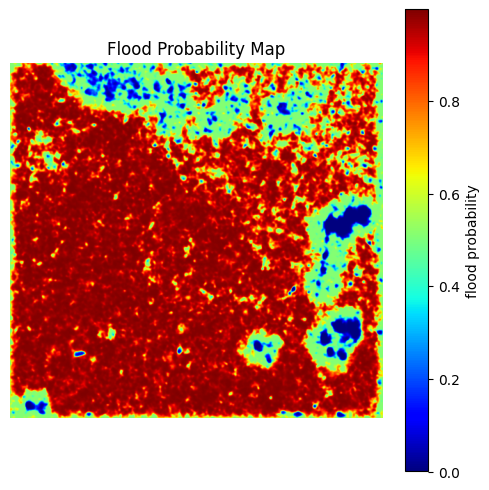

In [33]:
if prob_map.ndim == 3:
  prob_map_2d = prob_map.squeeze()
else:
  prob_map_2d = prob_map

print(prob_map_2d.shape)

plt.figure(figsize=(6, 6))
plt.imshow(prob_map_2d, cmap='jet')
plt.colorbar(label="flood probability")
plt.title("Flood Probability Map")
plt.axis('off')
plt.show()

In [34]:
low_thr = 0.3
high_thr = 0.6

severity_map = np.zeros_like(prob_map_2d)
severity_map[(prob_map_2d >= low_thr) & (prob_map_2d < high_thr)] = 1
severity_map[prob_map_2d >= high_thr] = 2

print("sverity classes: ")
print('0 -> no/ low, 1 -> moderate, 2 -> high')

sverity classes: 
0 -> no/ low, 1 -> moderate, 2 -> high


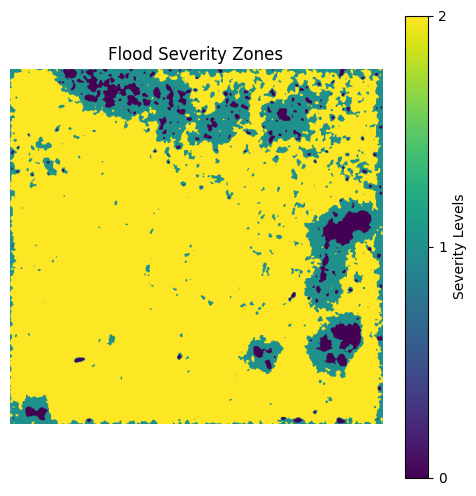

In [35]:
plt.figure(figsize=(6, 6))
plt.imshow(severity_map, cmap='viridis')
plt.colorbar(ticks = [0,1,2], label="Severity Levels")
plt.clim(0, 2)
plt.title("Flood Severity Zones")
plt.axis('off')
plt.show()

In [36]:
OUTPUT_DIR = '/content/drive/MyDrive/flood_detection_project/results'

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(OUTPUT_DIR)

/content/drive/MyDrive/flood_detection_project/results


In [37]:
# Save probability map as numpy array
np.save(os.path.join(OUTPUT_DIR, "flood_probability_map.npy"), prob_map_2d)

# Save probability map as image
plt.figure(figsize=(6, 6))
plt.imshow(prob_map_2d, cmap="jet")
plt.colorbar(label="Flood Probability")
plt.title("Flood Probability Map")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "flood_probability_map.png"), dpi=300, bbox_inches="tight")
plt.close()

print("Flood probability map saved")


Flood probability map saved


In [38]:
np.save(os.path.join(OUTPUT_DIR, "flood_severity_map.npy"), severity_map)

plt.figure(figsize=(6, 6))
plt.imshow(severity_map, cmap="viridis")
plt.colorbar(ticks=[0, 1, 2], label="Severity Level")
plt.clim(0, 2)
plt.title("Flood Severity Zones")
plt.axis("off")
plt.savefig(os.path.join(OUTPUT_DIR, "flood_severity_zones.png"), dpi=300, bbox_inches="tight")
plt.close()

print("Flood severity map saved")


Flood severity map saved


In [39]:
total_pixels = severity_map.size

low_pixels = np.sum(severity_map == 0)
moderate_pixels = np.sum(severity_map == 1)
high_pixels = np.sum(severity_map == 2)

stats = {
    "Low/No flood (%)": 100 * low_pixels / total_pixels,
    "Moderate flood (%)": 100 * moderate_pixels / total_pixels,
    "High flood (%)": 100 * high_pixels / total_pixels
}

stats


{'Low/No flood (%)': np.float64(4.039616371268656),
 'Moderate flood (%)': np.float64(17.538042210820894),
 'High flood (%)': np.float64(78.42234141791045)}

In [40]:
def run_inference_and_save(X, idx):
    X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(X_tensor)
        prob = torch.sigmoid(logits).squeeze().cpu().numpy()

    plt.figure(figsize=(5, 5))
    plt.imshow(prob, cmap="jet")
    plt.colorbar()
    plt.title(f"Flood Probability Map (Sample {idx})")
    plt.axis("off")
    plt.savefig(os.path.join(OUTPUT_DIR, f"prob_map_sample_{idx}.png"),
                dpi=300, bbox_inches="tight")
    plt.close()


# Run for 3 flood-positive test samples
count = 0
for X, y in test_data:
    if y == 1:
        run_inference_and_save(X, count)
        count += 1
    if count == 3:
        break

print("Saved probability maps for multiple test samples")


Saved probability maps for multiple test samples


Metrics


In [41]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix

In [43]:
y_true= []
y_pred = []
y_score = []

model.eval()

with torch.no_grad():
  for X_np, y in test_data:
    X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(0).to(device)
    logits = model(X)

    probs = torch.sigmoid(logits)

    event_prob = probs.mean().item()

    pred = 1 if event_prob > 0.5 else 0

    y_true.append(y)
    y_pred.append(pred)
    y_score.append(event_prob)

print("finished inference on test set")

finished inference on test set


In [46]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

acc = accuracy_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print(f"acc: {acc:.3f}")
print(f"recall: {recall:.3f}")
print(f"f1: {f1:.3f}")

acc: 0.683
recall: 0.833
f1: 0.755


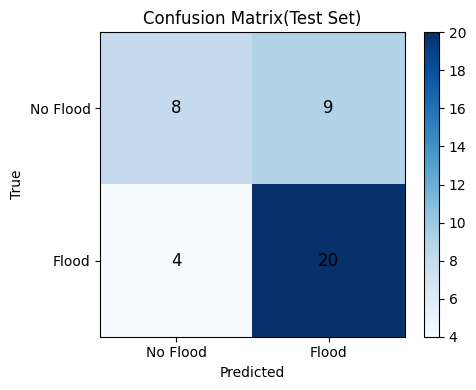

In [47]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

for i in range(2):
  for j in range(2):
    plt.text(j,i, cm[i, j], ha='center', va='center', fontsize=12)

plt.xticks([0,1], ["No Flood", "Flood"])
plt.yticks([0,1], ["No Flood", "Flood"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title('Confusion Matrix(Test Set)')
plt.tight_layout()
plt.show()